# 04 · Beijing PM2.5 — Pollution Forecasting & Exceedance Warning

## Part 4 — Pollution Forecasting (in depth)

Now the payoff of the whole study. The EDA found pollution is **persistent** (sticky hour-to-hour),
**multi-seasonal** (daily + winter), and **weather-driven** (wind disperses it). We turn that into a
**24-hour-ahead** forecast of PM2.5 — the operational "what will tomorrow's air be?" task — and judge
it two ways:

1. as a **regression** (how close are the numbers?), and
2. as an **air-quality warning system** (do we correctly flag the **hazardous** hours?) — the part
   that actually matters for public health.

We also confront the hardest, most honest question for any pollution model: **can it predict the
extremes** — the airpocalypse spikes — or does it shrug them off?

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import lightgbm as lgb
from sklearn.linear_model import LinearRegression
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from src import forecasting as fc

g = pd.read_csv(data.DATA_PROC / "beijing_imputed.csv", parse_dates=["datetime"]).set_index("datetime")
y = g["pm25"]
# 24h-ahead-safe features: any lag >=24h is known at the forecast origin.
g["lag24"] = y.shift(24); g["lag168"] = y.shift(168); g["lag_dayavg"] = y.shift(24).rolling(24).mean()
g["hour"] = g.index.hour; g["month"] = g.index.month; g["dow"] = g.index.dayofweek
g["wdir"] = g["wind_dir"].astype("category").cat.codes
WEATHER = ["TEMP","DEWP","PRES","Iws","Is","Ir"]; CAL = ["hour","month","dow","wdir"]; LAGS = ["lag24","lag168","lag_dayavg"]
g = g.dropna(subset=LAGS)
split = g.index.max() - pd.Timedelta(days=90)
tr, te = g[g.index <= split], g[g.index > split]
real = (~te["pm25_was_imputed"]).to_numpy()      # score only where the test truth is REAL, not imputed
yte = te["pm25"].to_numpy(); scale = tr["pm25"].to_numpy()
print("train:", tr.index.min().date(), "->", tr.index.max().date(), "| test (90d):", len(te), "h |",
      "real test points: %.0f%%" % (100*real.mean()))

setup ok | numpy 2.1.3 | pandas 2.3.3


train: 2010-01-08 -> 2014-10-02 | test (90d): 2160 h | real test points: 98%


### 1. The task and a fair yardstick

**Horizon: 24 hours ahead.** Why not next-hour? Because PM2.5 is *so* persistent hour-to-hour
(autocorrelation 0.97) that next-hour forecasting is trivial — last hour's value wins. A day ahead is
the useful, *non-trivial* task: the EDA showed same-hour-yesterday correlation is only ~0.40.

**Honest evaluation.** We trained features on the Part-3 imputed series (so lags exist everywhere),
but we **score only on test hours whose truth is real**, never on imputed values. Metrics: MAE /
RMSE / **MASE** (vs the seasonal-naive). As in the bike practice, using weather as a predictor
assumes a weather *forecast* — a caveat we accept here.

### 2. Baselines — persistence & climatology

In [2]:
def score(p):
    m = fc.forecast_metrics(yte[real], np.clip(p, 0, None)[real], scale, 24)
    return [m["MAE"], m["RMSE"], m["MASE"]]
naive = te["lag24"].to_numpy()                              # same hour yesterday
clim = tr.groupby([tr.month, tr.hour]).pm25.mean()
climp = np.array([clim.get((m, h)) for m, h in zip(te.month, te.hour)])
print("persistence (lag24):", [round(x,1) for x in score(naive)])
print("climatology        :", [round(x,1) for x in score(climp)])
print("-> both have MASE > 1: a day-ahead pollution forecast is genuinely hard for naive methods.")

persistence (lag24): [np.float64(90.1), np.float64(125.8), np.float64(1.3)]
climatology        : [np.float64(87.5), np.float64(109.2), np.float64(1.3)]
-> both have MASE > 1: a day-ahead pollution forecast is genuinely hard for naive methods.


### 3. Harmonic regression + weather

A classical model: Fourier terms for the **daily** and **yearly** cycles plus the **weather**
covariates (the meteorology the EDA found drives pollution). It should beat the baselines by using
wind, humidity, etc.

In [3]:
from numpy import sin, cos, pi
pos = np.arange(len(g))
F = np.hstack([np.column_stack([f(2*pi*k*pos/24) for k in range(1,6) for f in (sin,cos)]),
               np.column_stack([f(2*pi*k*pos/(24*365.25)) for k in range(1,3) for f in (sin,cos)])])
Xh = np.hstack([F, g[WEATHER].to_numpy()]); ntr = len(tr)
ph = LinearRegression().fit(Xh[:ntr], tr["pm25"].to_numpy()).predict(Xh[ntr:])
print("harmonic + weather:", [round(x,1) for x in score(ph)], "(MAE, RMSE, MASE) — beats the baselines")

harmonic + weather: [np.float64(55.4), np.float64(75.4), np.float64(0.8)] (MAE, RMSE, MASE) — beats the baselines


### 4. LightGBM with lags + weather — the workhorse

Gradient-boosted trees capture the **nonlinear** weather effects (the EDA's Pearson-vs-Spearman gaps)
and combine recent **persistence** (lags) with the meteorology.

In [4]:
feat = LAGS + WEATHER + CAL
mdl = lgb.LGBMRegressor(n_estimators=600, num_leaves=63, learning_rate=0.05, random_state=0, verbose=-1).fit(tr[feat], tr["pm25"])
pl = np.clip(mdl.predict(te[feat]), 0, None)
print("LightGBM + lags + weather:", [round(x,1) for x in score(pl)], "(MAE, RMSE, MASE)")

LightGBM + lags + weather: [np.float64(45.6), np.float64(65.1), np.float64(0.7)] (MAE, RMSE, MASE)


### 5. Scoreboard & forecast

                     MAE    RMSE  MASE
LGBM+lags+weather  45.64   65.06  0.68
harmonic+weather   55.40   75.43  0.82
climatology        87.47  109.23  1.30
persistence        90.08  125.79  1.34


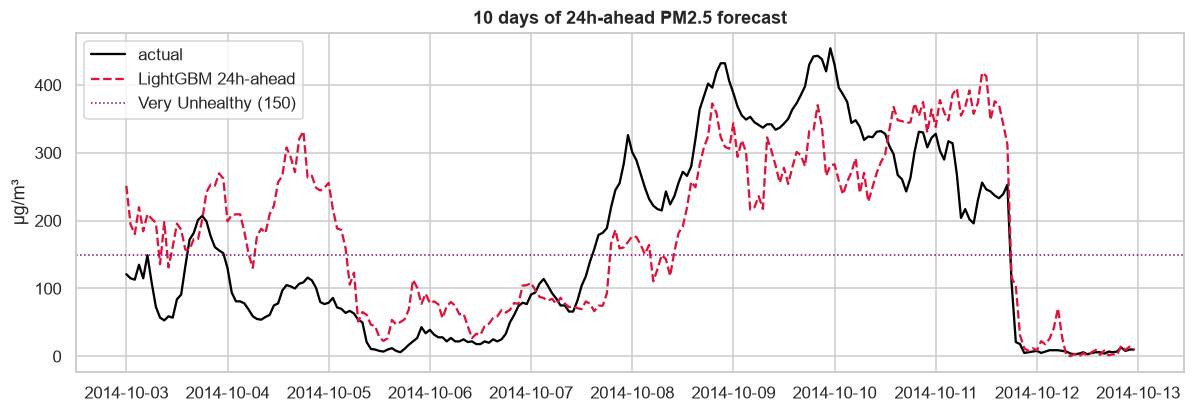

In [5]:
board = pd.DataFrame({"persistence": score(naive), "climatology": score(climp),
                      "harmonic+weather": score(ph), "LGBM+lags+weather": score(pl)},
                     index=["MAE","RMSE","MASE"]).T.sort_values("MASE").round(2)
print(board.to_string())
seg = te.iloc[:24*10]; segp = pl[:24*10]
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(seg.index, seg["pm25"], color="black", lw=1.5, label="actual")
ax.plot(seg.index, segp, "--", color="crimson", label="LightGBM 24h-ahead")
ax.axhline(150, color="purple", ls=":", lw=1, label="Very Unhealthy (150)")
ax.set_title("10 days of 24h-ahead PM2.5 forecast"); ax.legend(); ax.set_ylabel("µg/m³")
eda.savefig(fig, "p4_forecast.png"); plt.show()

### 6. The part that matters — forecasting the *hazardous* hours

A pollution forecast's real job is to **warn**. Reframe the regression as a **classification**: will
PM2.5 exceed the "Very Unhealthy" threshold (150 µg/m³)? We score precision/recall/F1 and the
confusion matrix on the LightGBM forecast.

base rate (hours actually >150): 28%
exceedance forecast — precision 0.77 | recall 0.75 | F1 0.76


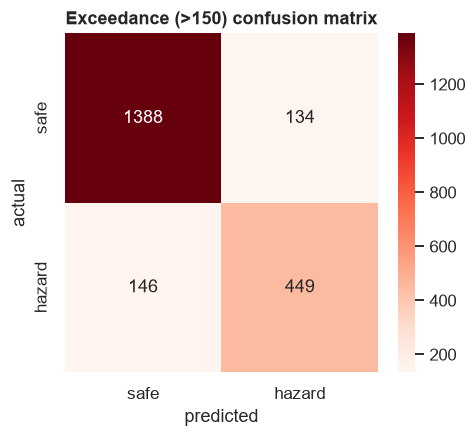

-> it catches ~3 in 4 hazardous hours at ~3-in-4 precision: a useful early-warning signal.


In [6]:
yt = yte[real]; pe = pl[real]
exc_t, exc_p = yt > 150, pe > 150
print("base rate (hours actually >150): %.0f%%" % (100*exc_t.mean()))
print("exceedance forecast — precision %.2f | recall %.2f | F1 %.2f" %
      (precision_score(exc_t, exc_p), recall_score(exc_t, exc_p), f1_score(exc_t, exc_p)))
cm = confusion_matrix(exc_t, exc_p)
fig, ax = plt.subplots(figsize=(4.6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=ax, xticklabels=["safe","hazard"], yticklabels=["safe","hazard"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title("Exceedance (>150) confusion matrix")
eda.savefig(fig, "p4_exceedance.png"); plt.show()
print("-> it catches ~3 in 4 hazardous hours at ~3-in-4 precision: a useful early-warning signal.")

### 7. The hard truth — models under-predict the extremes

The most dangerous hours are the hardest to forecast. Plot predicted vs actual: at the high end the
cloud sits **below** the diagonal — the model **systematically under-predicts** the worst pollution,
because extreme spikes come from rare stagnation events a smooth model regresses away. This is the
key limitation to communicate with any pollution forecast.

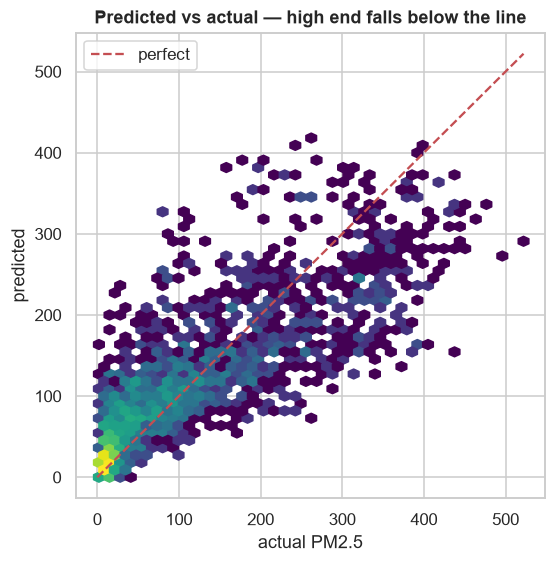

actual > 200 (422 h): mean actual 301 vs mean predicted 227  (under by 24%)
actual > 300 (212 h): mean actual 357 vs mean predicted 254  (under by 29%)
actual > 400 (29 h): mean actual 436 vs mean predicted 299  (under by 31%)


In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.hexbin(yt, pe, gridsize=40, cmap="viridis", mincnt=1, bins="log")
lim = max(yt.max(), pe.max()); ax.plot([0, lim], [0, lim], "r--", label="perfect")
ax.set_xlabel("actual PM2.5"); ax.set_ylabel("predicted"); ax.set_title("Predicted vs actual — high end falls below the line"); ax.legend()
eda.savefig(fig, "p4_underprediction.png"); plt.show()
for thr in [200, 300, 400]:
    hi = yt > thr
    if hi.sum(): print("actual > %d (%d h): mean actual %.0f vs mean predicted %.0f  (under by %.0f%%)"
                        % (thr, hi.sum(), yt[hi].mean(), pe[hi].mean(), 100*(1 - pe[hi].mean()/yt[hi].mean())))

### 8. What drives the forecast?

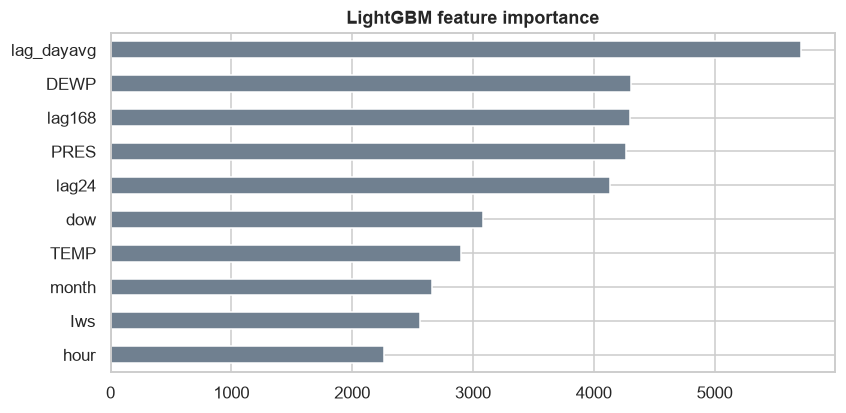

top drivers: ['lag_dayavg', 'DEWP', 'lag168', 'PRES', 'lag24', 'dow']
-> recent pollution (lags) + weather (dew point, pressure) — the meteorology the EDA flagged.


In [8]:
imp = pd.Series(mdl.feature_importances_, index=feat).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8.5, 4))
imp.head(10)[::-1].plot.barh(ax=ax, color="slategray"); ax.set_title("LightGBM feature importance")
eda.savefig(fig, "p4_importance.png"); plt.show()
print("top drivers:", list(imp.head(6).index))
print("-> recent pollution (lags) + weather (dew point, pressure) — the meteorology the EDA flagged.")

### Takeaways

- **Day-ahead pollution forecasting is non-trivial**: naive persistence and climatology *lose to the
  seasonal-naive* (MASE > 1), but adding **weather + lags** wins decisively — **LightGBM MASE ≈ 0.68**,
  roughly half the error of persistence.
- The model is a genuine **early-warning system**: it flags "Very Unhealthy" (>150) hours at **F1 ≈
  0.76** — catching ~3 of 4 hazardous hours.
- **But it under-predicts the extremes** (actual >300: ~360 vs ~250 forecast): smooth models regress
  the rare airpocalypse spikes toward the mean — the single most important caveat for a pollution
  forecast, and a motivation for extreme-value or quantile methods.
- **Drivers match the EDA**: recent pollution (persistence) + **weather (dew point, pressure)** — the
  meteorology and stickiness we found are exactly what the forecast leans on.

*This completes a full air-quality study (Parts 0–4): clean → extensive EDA → evaluated imputation →
forecasting, with the honest limitation (extremes) made explicit.*